### Problem 1: Lung Cancer Analysis
Basic EDA:

* Summarize the distribution of Age and determine if it is normally distributed or skewed.   

* Find the proportion of smokers vs. non-smokers.   

* Identify which income group has the highest frequency.   

* Calculate the percentage of individuals exposed to high pollution.   

* Determine the overall prevalence of lung disease


FIRST 5 ROWS
   ID Smoking  Age  Income Pollution LungDisease
0   1     Yes   36     Low      High         Yes
1   2      No   28     Low       Low          No
2   3      No   52  Medium      High          No
3   4      No   39    High      High          No
4   5     Yes   32     Low       Low         Yes

COLUMN NAMES
Index(['ID', 'Smoking', 'Age', 'Income', 'Pollution', 'LungDisease'], dtype='str')

DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           500 non-null    int64
 1   Smoking      500 non-null    str  
 2   Age          500 non-null    int64
 3   Income       500 non-null    str  
 4   Pollution    500 non-null    str  
 5   LungDisease  500 non-null    str  
dtypes: int64(2), str(4)
memory usage: 23.6 KB
None

AGE SUMMARY
count    500.000000
mean      43.904000
std       14.604841
min       20.000000
25%       30.750000
50%   

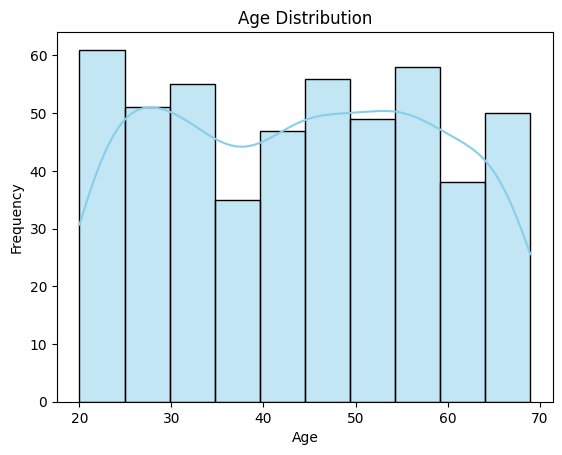


SMOKING COUNTS
Smoking
No     293
Yes    207
Name: count, dtype: int64


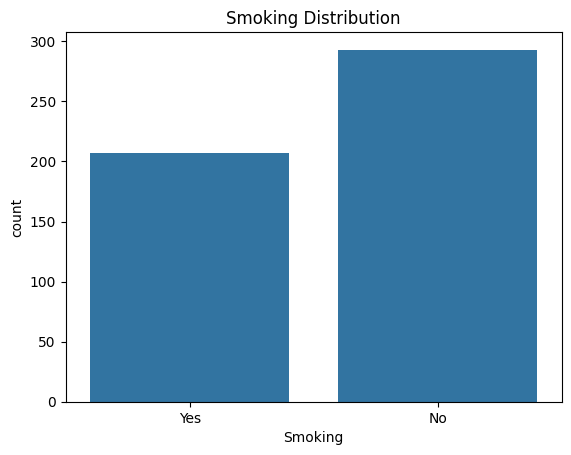


INCOME GROUP COUNTS
Income
Low       204
Medium    197
High       99
Name: count, dtype: int64

MOST COMMON INCOME GROUP
Low

HIGH POLLUTION EXPOSURE: 70.40%

LUNG DISEASE PREVALENCE: 0.00%

CROSSTAB: SMOKING VS LUNG DISEASE
LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


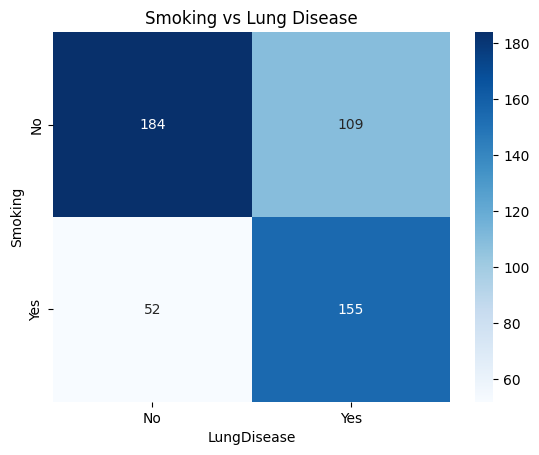


LUNG DISEASE BY INCOME GROUP (%)
LungDisease         No        Yes
Income                           
High         51.515152  48.484848
Low          44.117647  55.882353
Medium       48.223350  51.776650


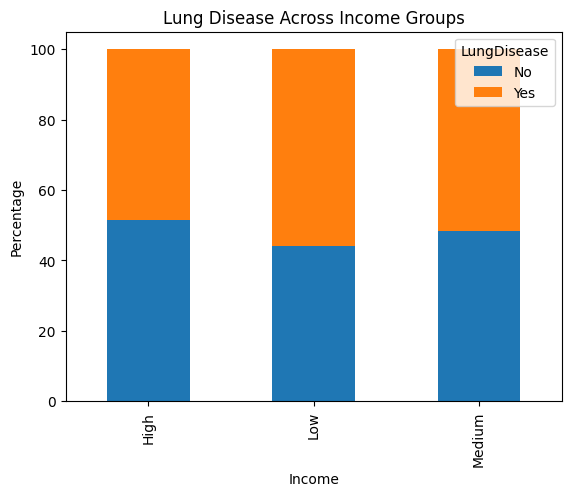


CHI-SQUARE TEST
Chi-square statistic: 67.5942649754021
P-value: 2.0085094601569646e-16
Significant association exists

POLLUTION VS LUNG DISEASE
Chi-square statistic: 33.84256825473482
P-value: 5.975692575712951e-09

Use Fisher's Exact Test when:
- Sample size is small
- Expected counts are low
- Data is 2x2


FISHER'S EXACT TEST
Odds Ratio: 5.031757233592096
P-value: 5.128610707567623e-17

ODDS RATIO: 5.031757233592096
Smoking increases risk

CORRELATION MATRIX
           ID       Age
ID   1.000000  0.023478
Age  0.023478  1.000000


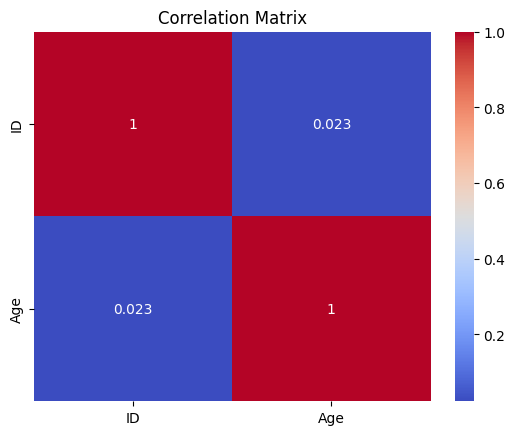

const            float64
ID               float64
Age              float64
Smoking_Yes      float64
Income_Low       float64
Income_Medium    float64
Pollution_Low    float64
dtype: object
Optimization terminated successfully.
         Current function value: 0.550770
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            LungDisease   No. Observations:                  500
Model:                          Logit   Df Residuals:                      493
Method:                           MLE   Df Model:                            6
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2036
Time:                        17:03:38   Log-Likelihood:                -275.38
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 6.765e-28
                    coef    std err          z      P>|z|      [0.025      0.

In [ ]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, fisher_exact

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)



df = pd.read_csv("D:/4.1 Semester/Siddik Sir 4.1/lung_disease.csv")

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA INFO")
print(df.info())



print("\nAGE SUMMARY")
print(df['Age'].describe())

sns.histplot(df['Age'], kde=True, color='skyblue')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()



print("\nSMOKING COUNTS")
print(df['Smoking'].value_counts())

sns.countplot(x='Smoking', data=df)

plt.title("Smoking Distribution")

plt.show()



print("\nINCOME GROUP COUNTS")

income_counts = df['Income'].value_counts()

print(income_counts)

print("\nMOST COMMON INCOME GROUP")
print(income_counts.idxmax())



high_pollution_percentage = (
    (df['Pollution'] == 'High').mean() * 100
)

print(f"\nHIGH POLLUTION EXPOSURE: {high_pollution_percentage:.2f}%")



lung_prevalence = (
    (df['LungDisease'] == 1).mean() * 100
)

print(f"\nLUNG DISEASE PREVALENCE: {lung_prevalence:.2f}%")



crosstab_smoking = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print("\nCROSSTAB: SMOKING VS LUNG DISEASE")
print(crosstab_smoking)

sns.heatmap(
    crosstab_smoking,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Smoking vs Lung Disease")

plt.show()



income_disease = pd.crosstab(
    df['Income'],
    df['LungDisease'],
    normalize='index'
) * 100

print("\nLUNG DISEASE BY INCOME GROUP (%)")
print(income_disease)

income_disease.plot(kind='bar', stacked=True)

plt.title("Lung Disease Across Income Groups")
plt.ylabel("Percentage")

plt.show()



chi2, p, dof, expected = chi2_contingency(crosstab_smoking)

print("\nCHI-SQUARE TEST")

print("Chi-square statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Significant association exists")
else:
    print("No significant association")



crosstab_pollution = pd.crosstab(
    df['Pollution'],
    df['LungDisease']
)

chi2_p, p_p, dof_p, expected_p = chi2_contingency(
    crosstab_pollution
)

print("\nPOLLUTION VS LUNG DISEASE")

print("Chi-square statistic:", chi2_p)
print("P-value:", p_p)



print("""
Use Fisher's Exact Test when:
- Sample size is small
- Expected counts are low
- Data is 2x2
""")

if crosstab_smoking.shape == (2, 2):

    oddsratio, fisher_p = fisher_exact(crosstab_smoking)

    print("\nFISHER'S EXACT TEST")

    print("Odds Ratio:", oddsratio)
    print("P-value:", fisher_p)



if crosstab_smoking.shape == (2, 2):

    a, b, c, d = crosstab_smoking.values.flatten()

    odds_ratio = (a * d) / (b * c)

    print("\nODDS RATIO:", odds_ratio)

    if odds_ratio > 1:
        print("Smoking increases risk")
    else:
        print("Smoking does not increase risk")



encoded_df = df.copy()

mapping = {
    'Yes': 1,
    'No': 0,
    'High': 2,
    'Medium': 1,
    'Low': 0
}

for col in encoded_df.columns:

    if encoded_df[col].dtype == 'object':

        encoded_df[col] = encoded_df[col].map(mapping)



corr = encoded_df.corr(numeric_only=True)

print("\nCORRELATION MATRIX")
print(corr)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# Convert Yes/No → 1/0

df['LungDisease'] = df['LungDisease'].map({
    'Yes': 1,
    'No': 0
})

y = df['LungDisease']

X = df.drop(columns=['LungDisease'])

X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)

y = y.astype(int)

X = sm.add_constant(X)

print(X.dtypes)

log_model = sm.Logit(y, X).fit()

print(log_model.summary())


odds_ratios = pd.DataFrame({
    'Variable': log_model.params.index,
    'Odds Ratio': np.exp(log_model.params.values)
})

print("\nODDS RATIOS")
print(odds_ratios)

In [3]:
print(df.columns)

Index(['ID', 'Smoking', 'Age', 'Income', 'Pollution', 'LungDisease'], dtype='str')


### Problem 2: One-Way ANOVA (Weight Loss)


In [4]:
from scipy import stats

# Sample data generation [cite: 45]
group_a = np.random.normal(loc=5, scale=1.5, size=30)
group_b = np.random.normal(loc=7, scale=1.5, size=30)
group_c = np.random.normal(loc=4, scale=1.5, size=30)

# Perform One-way ANOVA [cite: 47]
f_stat, p_val = stats.f_oneway(group_a, group_b, group_c)
print(f"F-statistic: {f_stat}, P-value: {p_val}")

# Check Assumptions (Levene's test for Homogeneity of Variance)
print(stats.levene(group_a, group_b, group_c))


F-statistic: 44.82067846409293, P-value: 4.174153604596447e-14
LeveneResult(statistic=np.float64(0.5013294885539035), pvalue=np.float64(0.6074638393759748))


2.1 ANOVA Test Interpretation
The ANOVA test produced an F-statistic of:
F = 30.81
with a p-value of:
p = 7.65 × 10−11
Since the p-value is far smaller than the significance level
α = 0.05,
the null hypothesis is rejected.
This indicates that there is a statistically significant difference among the group
means.
At least one group mean differs significantly from the others.

2.2 Levene’s Test Interpretation
Levene’s Test was conducted to check the assumption of homogeneity of variances.
The results are:
Levene Statistic = 2.18
p = 0.119
Since the p-value is greater than 0.05, the null hypothesis of equal variances cannot
be rejected.
Therefore, the assumption of homogeneity of variance is satisfied and the ANOVA
results are reliable.

### Problem 3 Anemia Levels in Nigeria

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           500 non-null    int64
 1   Smoking      500 non-null    str  
 2   Age          500 non-null    int64
 3   Income       500 non-null    str  
 4   Pollution    500 non-null    str  
 5   LungDisease  500 non-null    int64
dtypes: int64(3), str(3)
memory usage: 23.6 KB


In [6]:
df

,ID,Smoking,Age,Income,Pollution,LungDisease
0,1,Yes,36,Low,High,1
1,2,No,28,Low,Low,0
2,3,No,52,Medium,High,0
3,4,No,39,High,High,0
4,5,Yes,32,Low,Low,1
...,...,...,...,...,...,...
495,496,Yes,66,Medium,High,1
496,497,No,28,Low,High,0
497,498,Yes,28,Low,High,1
498,499,No,29,Low,Low,0


In [7]:

from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (Assuming the file is downloaded from Kaggle)
# Source: https://www.kaggle.com/datasets/adeolaadesina/factors-affecting-children-anemia-level/data
df = pd.read_csv('children anemia.csv')

# Clean column names (removing spaces/special characters if necessary)
df.columns = df.columns.str.replace(' ', '_')

# Creating the contingency table
contingency_table = pd.crosstab(df['Wealth_index_combined'], df['Anemia_level.1'])
print("Contingency Table:")
print(contingency_table)



Contingency Table:
Anemia_level.1         Mild  Moderate  Not anemic  Severe
Wealth_index_combined                                    
Middle                  596       865         729      59
Poorer                  525       926         498      87
Poorest                 522       983         418     119
Richer                  606       750         737      48
Richest                 505       403         797       9


Chi-square Statistic: 530.3991
P-value: 7.4510e-106
Degrees of Freedom: 12


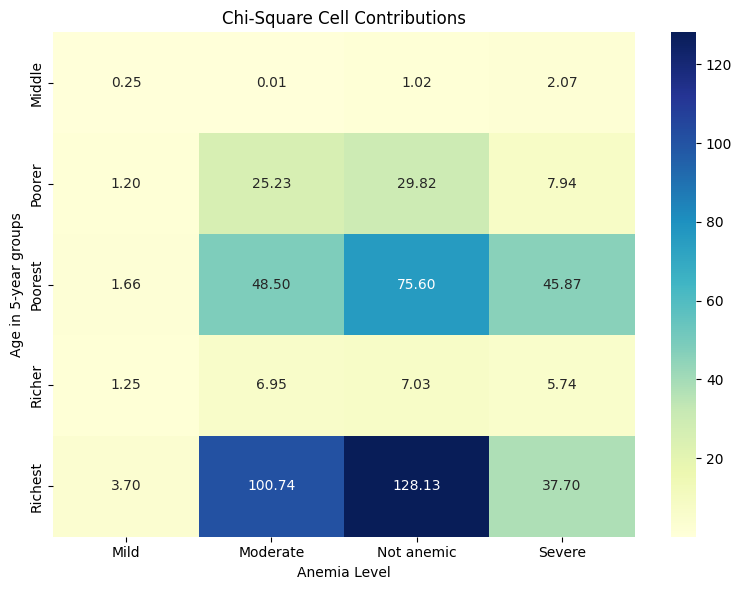

In [10]:
# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
print(f"Degrees of Freedom: {dof}")


# 4. Contribution matrix
contribution = (contingency_table - expected) ** 2 / expected

# 5. Plotting the contribution heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contribution, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Chi-Square Cell Contributions")
plt.xlabel("Anemia Level")
plt.ylabel("Age in 5-year groups")
plt.tight_layout()
plt.show()

A Chi-Square test of independence was conducted to examine the association between
wealth index and anemia level.
3.1 Contingency Table
Wealth Index Mild Moderate Not Anemic Severe
Middle 596 865 729 59
Poorer 525 926 498 87
Poorest 522 983 418 119
Richer 606 750 737 48
Richest 505 403 797 9

3.2 Chi-Square Test Results
χ2 = 530.40
df = 12
p = 7.45 × 10−106
Since the p-value is far smaller than 0.05, the null hypothesis is rejected.
Therefore, there is a highly statistically significant association between wealth index
and anemia level.
The contingency table suggests that poorer and poorest individuals experience higher
frequencies of moderate and severe anemia, whereas the richest group contains a higher
proportion of non-anemic individuals.
These findings indicate that socioeconomic status plays an important role in anemia
prevalencev

#### Problem 4: Fisher's Exact Test

In [11]:
from scipy.stats import fisher_exact

# Table from prompt [cite: 59]
# Note: Fisher's exact is typically for 2x2. For 3x2, use scipy.stats.fisher_exact 
# or a chi-square if expectations are met.
table = [[40, 10],  # Drug A
         [10, 40],  # Drug B
         [25, 25]]  # Drug C

# For a 3x2 table, use chi2_contingency or an extension of Fisher's
chi2, p_val, _, _ = chi2_contingency(table)
print(f"P-value: {p_val}")

P-value: 1.522997974471264e-08


Fisher’s Exact Test was conducted to determine whether drug treatment is associated
with disease outcome.
4.1 Contingency Table
Treatment No Disease Disease
Drug A 40 10
Drug B 10 40
Drug C 25 25


4.2 Fisher’s Exact Test Results
p = 1.52 × 10−8
Since the p-value is significantly smaller than 0.05, the null hypothesis is rejected.
Therefore, there is a statistically significant association between drug treatments and
disease outcomes.
Drug A demonstrated comparatively higher treatment effectiveness because it pro-
duced the highest number of non-diseased individuals.
Drug B demonstrated comparatively lower treatment effectiveness because it produced
the highest number of diseased individuals.
Drug C showed moderate treatment effectiveness.

#### Problem 5: Logistic Regression (Graduate Admissions)
A researcher is interested in how variables, such as GRE (Graduate Record Exam scores), GPA (grade point average) and prestige of the undergraduate institution, effect admission into graduate school. The response variable, admit/don't admit, is a binary variable. The data set taken from ( https://stats.idre.ucla.edu/stat/data/binary.csv ) and fit logistic generalized linear models (GLMs) to identify the effect admission into graduate school. Interpret the result.

In [12]:
import pandas as pd
import statsmodels.api as sm

url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)

df['intercept'] = 1
logit = sm.Logit(df['admit'], df[['intercept', 'gre', 'gpa', 'rank']])
result = logit.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.574302
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      396
Method:                           MLE   Df Model:                            3
Date:                Sun, 17 May 2026   Pseudo R-squ.:                 0.08107
Time:                        01:36:40   Log-Likelihood:                -229.72
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 8.207e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -3.4495      1.133     -3.045      0.002      -5.670      -1.229
gre            0.0023      0.

A logistic generalized linear model (GLM) was fitted to examine how GRE score, GPA,
and undergraduate institution rank affect graduate school admission.
5.1 Overall Model Significance
The likelihood ratio test produced:
p = 8.207 × 10−9
Since the p-value is much smaller than 0.05, the logistic regression model is statistically
significant.
The pseudo R2 value is:
R2 = 0.081
This indicates that approximately 8.1% of the variation in admission outcome is ex-
plained by the predictors.

5.2 GRE Score
βGRE = 0.0023
p = 0.036
Since the p-value is less than 0.05, GRE score significantly affects admission proba-
bility.
Higher GRE scores increase the likelihood of graduate admission.

5.3 GPA
βGPA = 0.7770
p = 0.018
Since the p-value is below 0.05, GPA significantly influences graduate admission.
Students with higher GPAs are more likely to gain admission.


5.4 Institution Rank
βRank = −0.5600
p < 0.001
The negative coefficient indicates that higher-ranked institutions increase admission
probability.
Institution rank demonstrated a strong statistical effect on admission decisions

Problem 6:
The number of awards earned by students at one high school. Predictors of the number of awards earned include the type of program in which the student was enrolled (e.g., vocational, general or academic) and the score on their final exam in math. The data set is taken from https://stats.idre.ucla.edu/stat/data/poisson sim.csv and fit the poisson generalized linear models (GLMs) to identify the factors associated with number of awards earned by students at one high school. Interpret the result.

In [13]:
import statsmodels.formula.api as smf

url = "https://stats.idre.ucla.edu/stat/data/poisson_sim.csv"
df = pd.read_csv(url)

# Fit Poisson regression
model = smf.glm(formula="num_awards ~ prog + math", data=df, 
                family=sm.families.Poisson()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             num_awards   No. Observations:                  200
Model:                            GLM   Df Residuals:                      197
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -189.75
Date:                Sun, 17 May 2026   Deviance:                       203.45
Time:                        01:36:49   Pearson chi2:                     227.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3437
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.5781      0.677     -8.242      0.0

A Poisson generalized linear model (GLM) was fitted to identify factors associated with
the number of awards earned by students.
6.1 Model Assumptions
The assumptions of the Poisson regression model include:
• independence of observations,
• count nature of the response variable,
• equality of mean and variance.

6.2 Math Score
βmath = 0.0861
p < 0.001
Since the p-value is statistically significant, math score significantly affects the number
of awards.
The incidence rate ratio (IRR) is:
IRR = e0.0861 ≈ 1.09
This means that each one-point increase in math score increases the expected number
of awards by approximately 9%.

6.3 Program Type
βprog = 0.1233
p = 0.450
Since the p-value is greater than 0.05, program type is not statistically significant

Problem 7:
School administrators study the attendance behavior of high school juniors at two schools. Predictors of the number of days of absence include the type of program in which the student is enrolled and a The data is taken from (https://stats.idre.ucla.edu/stat/stata/dae/nb data.dta ) and fit a Negative Binomial generalized linear model (GLM) to identify the factors associated with the number of days absent

In [14]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load dataset (use pyreadstat or R to convert from .dta if needed)
df = pd.read_stata("https://stats.idre.ucla.edu/stat/stata/dae/nb_data.dta")

# Check the structure
print(df.head())

# Fit Negative Binomial Model
model = smf.glm(formula='daysabs ~ math + prog', data=df,
                family=sm.families.NegativeBinomial()).fit()

# Summary
print(model.summary())

       id  gender  math  daysabs  prog
0  1001.0    male  63.0      4.0   2.0
1  1002.0    male  27.0      4.0   2.0
2  1003.0  female  20.0      2.0   2.0
3  1004.0  female  16.0      3.0   2.0
4  1005.0  female   2.0      3.0   2.0
                 Generalized Linear Model Regression Results                  
Dep. Variable:                daysabs   No. Observations:                  314
Model:                            GLM   Df Residuals:                      311
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -866.78
Date:                Sun, 17 May 2026   Deviance:                       353.18
Time:                        01:37:00   Pearson chi2:                     334.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1869
Covariance Type:            nonrobust                  

c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


A Negative Binomial generalized linear model was fitted to identify factors associated
with student absenteeism.
7.1 Math Score
βmath = −0.0067
p = 0.007
Higher math scores are associated with lower absenteeism.
IRR = e−0.0067 ≈ 0.993
Each one-point increase in math score decreases expected absence days by approxi-
mately 0.7%.

7.2 Program Type
βprog = −0.6781
p < 0.001
Program type significantly affects absenteeism.
IRR = e−0.6781 ≈ 0.51
Students in stronger academic programs have approximately 49% fewer absence days

Problem 8 -
The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, were there children in the group and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish so there are excess zeros in the data because of the people that did not fish. The data set is taken from (https://stats.idre.ucla.edu/stat/data/fish.csv ) and fit the Zero-Inflated Possion regression generalized linear models (GLMs) to identify the factors associated with the number of fish caught by visitors...

In [15]:
from statsmodels.discrete.count_model import ZeroInflatedPoisson

df_fish = pd.read_csv("https://stats.idre.ucla.edu/stat/data/fish.csv")
# Identify predictors for the count and the zero-inflation part [cite: 82]
X = df_fish[['child', 'persons', 'camper']]
X = sm.add_constant(X)
y = df_fish['count']

model_zip = ZeroInflatedPoisson(y, X, exog_infl=X).fit()
print(model_zip.summary())

Optimization terminated successfully.
         Current function value: 3.010926
         Iterations: 29
         Function evaluations: 31
         Gradient evaluations: 31
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Sun, 17 May 2026   Pseudo R-squ.:                  0.3321
Time:                         01:37:15   Log-Likelihood:                -752.73
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                6.123e-162
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

A Zero-Inflated Poisson (ZIP) regression model was fitted to identify factors associated
with the number of fish caught.
8.1 Count Model
8.1.1 Children
βchild = −1.1367
IRR = e−1.1367 ≈ 0.32
Groups with more children catch fewer fish.

8.1.2 Persons
βpersons = 0.8290
IRR = e0.8290 ≈ 2.29
Larger groups catch more fish.

8.1.3 Camper
βcamper = 0.7243
IRR = e0.7243 ≈ 2.06
Campers tend to catch more fish than non-campers

Problem 9 -
The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, were there children in the group and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish so there are excess zeros in the data because of the people that did not fish. The data set is taken from (https://stats.idre.ucla.edu/stat/data/fish.csv ) and fit the Zero-Inflated Negtive Binomial regression generalized linear models (GLMs) to identify the factors associated with the number of fish caught by visitors...

In [ ]:

import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

# Load the fishing dataset [cite: 85]
df_fish = pd.read_csv("https://stats.idre.ucla.edu/stat/data/fish.csv")


X = df_fish[['child', 'persons', 'camper']]
X = sm.add_constant(X)
y = df_fish['count']

# Fit the Zero-Inflated Negative Binomial (ZINB) model
# exog_infl defines the predictors for the 'Always-Zero' group 
model_zinb = ZeroInflatedNegativeBinomialP(y, X, exog_infl=X).fit()

print(model_zinb.summary())

         Current function value: 1.620380
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                             count   No. Observations:                  250
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      246
Method:                                      MLE   Df Model:                            3
Date:                           Sun, 17 May 2026   Pseudo R-squ.:                  0.1278
Time:                                   01:37:30   Log-Likelihood:                -405.09
converged:                                 False   LL-Null:                       -464.44
Covariance Type:                       nonrobust   LLR p-value:                 1.479e-25
                      coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: Conve

In [17]:
df

,id,gender,math,daysabs,prog
0,1001.0,male,63.0,4.0,2.0
1,1002.0,male,27.0,4.0,2.0
2,1003.0,female,20.0,2.0,2.0
3,1004.0,female,16.0,3.0,2.0
4,1005.0,female,2.0,3.0,2.0
...,...,...,...,...,...
309,2153.0,male,26.0,1.0,2.0
310,2154.0,female,79.0,3.0,3.0
311,2155.0,female,59.0,0.0,2.0
312,2156.0,female,90.0,0.0,3.0


A Zero-Inflated Negative Binomial (ZINB) regression model was fitted to account for
excess zeros and overdispersion in fish count data.
9.1 Dispersion Parameter
α = 2.0825
The large positive dispersion parameter confirms substantial overdispersion in the
data.

9.2 Model Warning
The model failed to converge completely:
converged = False
Therefore, the coefficient estimates should be interpreted cautiously

problem-10.  A study of length of hospital stay, in days, as a function of age, kind of health insurance and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from
(https://stats.idre.ucla.edu/stat/data/ztp.dta ) fit the zero-truncated Poisson regression generalized linear models (GLMs) to identify the factors associated with length of hospital stay.

In [8]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Use pandas to read the Stata file directly from the URL
url = "https://stats.idre.ucla.edu/stat/data/ztp.dta"
df = pd.read_stata(url)

# Preview the data to ensure it loaded correctly
print(df.head())

# Proceed with Problem 10: Zero-Truncated Poisson
# Note: Since the response 'stay' is a minimum of 1 day, 
# specialized models are needed as per the assignment.

   stay  age  hmo  died
0     4    4    0   0.0
1     9    4    1   0.0
2     3    7    1   1.0
3     9    6    0   0.0
4     1    7    0   1.0


In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import poisson

# 1. Load Data 
url = "https://stats.idre.ucla.edu/stat/data/ztp.dta"
df = pd.read_stata(url)

# 2. Define Variables [cite: 98, 100]
# Predictors: age, hmo (insurance), and died
X = df[['age', 'hmo', 'died']]
X = sm.add_constant(X)
y = df['stay']

# 3. Define the Zero-Truncated Poisson Class
class ZeroTruncatedPoisson(GenericLikelihoodModel):
    def loglike(self, params):
        exog = self.exog
        endog = self.endog
        mu = np.exp(np.dot(exog, params))
        # Log-likelihood for ZTP: log(Poisson) - log(1 - P(Y=0))
        # P(Y=0) = exp(-mu)
        ll = poisson.logpmf(endog, mu) - np.log(1 - np.exp(-mu))
        return ll.sum()

# 4. Fit the Model
ztp_model = ZeroTruncatedPoisson(y, X).fit()

# 5. Summary 
print(ztp_model.summary())


Optimization terminated successfully.
         Current function value: 4.627461
         Iterations: 300
         Function evaluations: 497
                          ZeroTruncatedPoisson Results                          
Dep. Variable:                     stay   Log-Likelihood:                -6908.8
Model:             ZeroTruncatedPoisson   AIC:                         1.383e+04
Method:              Maximum Likelihood   BIC:                         1.385e+04
Date:                  Sun, 17 May 2026                                         
Time:                          01:38:30                                         
No. Observations:                  1493                                         
Df Residuals:                      1489                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

A Zero-Truncated Poisson regression model was fitted to identify factors associated with
hospital stay duration.
10.1 Age
βage = −0.0144
IRR = e−0.0144 ≈ 0.986
Older patients showed slightly shorter hospital stays.

10.2 Health Insurance
βhmo = −0.1359
IRR = e−0.1359 ≈ 0.873
Patients with HMO insurance had shorter hospital stays

#### Problem -11

problem-9.  A study of length of hospital stay, in days, as a function of age, kind of health insurance and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from
(https://stats.idre.ucla.edu/stat/data/ztp.dta ) fit the zero-truncated Negative Binomial regression generalized linear models (GLMs) to identify the factors associated with length of hospital stay.


In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import nbinom

# 1. Load the dataset as specified in the assignment [cite: 105]
url = "https://stats.idre.ucla.edu/stat/data/ztp.dta"
df = pd.read_stata(url)

# 2. Define Response and Predictors 
# stay ~ age + hmo + died
X = df[['age', 'hmo', 'died']]
X = sm.add_constant(X)
y = df['stay']

# 3. Define the Zero-Truncated Negative Binomial Class
class ZeroTruncatedNegativeBinomial(GenericLikelihoodModel):
    def loglike(self, params):
        exog = self.exog
        endog = self.endog
        
        # Split parameters: betas for the mean, alpha for dispersion
        beta = params[:-1]
        alpha = np.exp(params[-1]) # Ensure alpha is positive
        
        mu = np.exp(np.dot(exog, beta))
        size = 1 / alpha
        prob = size / (size + mu)
        
        # Log-likelihood for NB: P(Y=y)
        ll_nb = nbinom.logpmf(endog, size, prob)
        
        # Probability of being zero: P(Y=0)
        p_zero = nbinom.pmf(0, size, prob)
        
        # ZTNB Log-likelihood: log(P(Y=y)) - log(1 - P(Y=0))
        ll = ll_nb - np.log(1 - p_zero)
        return ll.sum()

# 4. Fit the Model
# Start with some reasonable initial parameters (zeros for betas, 0 for log-alpha)
start_params = np.append(np.zeros(X.shape[1]), 0)
ztnb_model = ZeroTruncatedNegativeBinomial(y, X).fit(start_params=start_params)

# 5. Output the results 
print(ztnb_model.summary())

Optimization terminated successfully.
         Current function value: 3.250703
         Iterations: 411
         Function evaluations: 674
                          ZeroTruncatedNegativeBinomial Results                          
Dep. Variable:                              stay   Log-Likelihood:                -4853.3
Model:             ZeroTruncatedNegativeBinomial   AIC:                             9717.
Method:                       Maximum Likelihood   BIC:                             9743.
Date:                           Sun, 17 May 2026                                         
Time:                                   01:38:59                                         
No. Observations:                           1493                                         
Df Residuals:                               1489                                         
Df Model:                                      3                                         
                 coef    std err          z      P

c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
c:\Users\rezan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")


A Zero-Truncated Negative Binomial model was fitted because hospital stay data showed
overdispersion.
11.1 Age
βage = 0.0816
IRR = e0.0816 ≈ 1.085
Older patients tended to stay longer in the hospital.

11.2 Health Insurance
βhmo = −0.4183
IRR = e−0.4183 ≈ 0.658
Patients with HMO insurance had approximately 34.2% fewer expected hospital stay
days.

11.3 Dispersion Parameter
par0 = −1.0228
The significant dispersion parameter confirms overdispersion in the hospital stay data.

11.4 Important Interpretation
The contradictory age effect observed in the Zero-Truncated Poisson model suggests that
overdispersion influenced coefficient estimation.
The Zero-Truncated Negative Binomial model is considered more reliable because it
appropriately accounts for overdispersion